# Thesis Notebook — SRQ1 (DANSKVAND)

**Owner**: Enrico Manfron
**Institution**: Copenhagen Business School (MSc 2026)
**Created**: 2026-04-24

**Scope**: Single-category SRQ1 forecasting for `danskvand` (Nielsen Fabric).

**Design choices** (locked):
- **18 mutually-exclusive retailer chains** (no holding aggregates → no double counting)
- **Brand × retailer × month** aggregation grain
- **Optuna 50 trials × 2 algorithms** (LightGBM + XGBoost)
- **Walk-forward CV** for hyperparameter selection (5 folds, expanding window)
- Reference baseline: SeasonalNaive + Ridge

**Output dir**: `outputs_danskvand/`

---

# §0 — Setup

**Why**: imports, paths, constants, random seed. Must run before any other cell.

In [1]:
# §0 — Setup
import sys, json, time, io, warnings, pickle as pkl
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path("/Users/enricomanfron/Desktop/Thesis Maniflod")
sys.path.insert(0, str(PROJECT_ROOT))

CATEGORY = "danskvand"
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = PROJECT_ROOT / "docs" / "thesis" / "analysis" / f"outputs_{CATEGORY}"
FIGURE_DIR = OUTPUT_DIR / "figures"
PIPE_DIR   = OUTPUT_DIR / "pipelines"
for d in (OUTPUT_DIR, FIGURE_DIR, PIPE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Locked split dates (consistent across all 5 categories)
TRAIN_END  = pd.Timestamp("2025-02-01")
VAL_END    = pd.Timestamp("2025-08-01")

# Frozen min-periods filter (drop brands with sparse history)
MIN_PERIODS = 30

# 18 mutually-exclusive terminal retailer chains (verified to exist for danskvand)
CHANNEL_MAP = {
    "SUPERBRUGSEN": "SUPERBRUGSEN",
    "KVICKLY":      "KVICKLY",
    "BRUGSEN":      "BRUGSEN",
    "MENY":         "MENY",
    "SPAR":         "SPAR",
    "MIN KØBMAND":  "MIN_KOBMAND",
    "FØTEX":        "FOTEX",
    "BILKA":        "BILKA",
    "NETTO":        "NETTO",
    "REMA 1000":    "REMA_1000",
    "LØVBJERG":     "LOVBJERG",
    "NEMLIG.COM":   "NEMLIG_COM",
    "7-ELEVEN":     "7_ELEVEN",
    "OK PLUS":      "OK_PLUS",
    "CIRCLE K":     "CIRCLE_K",
    "Q8":           "Q8",
    "BFI SHELL":    "BFI_SHELL",
    "BFI EXTRA":    "BFI_EXTRA",
}

print(f"Category    : {CATEGORY}")
print(f"Output dir  : {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Channels    : {len(CHANNEL_MAP)} retailer chains")
print(f"Train end   : {TRAIN_END.date()}")
print(f"Val end     : {VAL_END.date()}")
print(f"Min periods : {MIN_PERIODS} non-zero months per brand")


Category    : danskvand
Output dir  : docs/thesis/analysis/outputs_danskvand
Channels    : 18 retailer chains
Train end   : 2025-02-01
Val end     : 2025-08-01
Min periods : 30 non-zero months per brand


/Users/enricomanfron/Desktop/Thesis Maniflod/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### §0 — Observations + Decisions

- All paths resolve correctly? _..._
- LightGBM + XGBoost + Optuna versions OK? _..._
- 18 retailer chains chosen (same across the 4 new categories for pooled coherence).

---

# §1 — Pull data from Nielsen DB + aggregate to (brand, channel, month)

**Why**: extract raw facts for `danskvand` from the DB, JOIN with dim_product (brand) and dim_period (month), filter to the 18 retailer chains, aggregate to brand-channel-month grain.

The DB query is schema-tolerant: if some columns (e.g. `sales_units_any_promo`) don't exist for this category, they're substituted with 0.

In [2]:
# §1 — Pull + aggregate from DB
from thesis.data.nielsen.scripts.nielsen_connector import get_connection

# Detect available columns in facts (categories have different schemas)
def get_facts_columns(conn, cat):
    cur = conn.cursor()
    cur.execute(
        "SELECT COLUMN_NAME FROM INFORMATION_SCHEMA.COLUMNS "
        "WHERE TABLE_NAME = ? AND TABLE_SCHEMA = 'dbo'",
        f"{cat}_clean_facts_v",
    )
    return {row[0] for row in cur.fetchall()}

print(f"Connecting to Nielsen Fabric...")
conn = get_connection()
print("Connected.\n")

available = get_facts_columns(conn, CATEGORY)
print(f"Facts columns available for {CATEGORY}: {len(available)} cols")
promo_expr        = "SUM(COALESCE(f.sales_units_any_promo, 0))" if "sales_units_any_promo" in available else "0"
sales_value_col   = "sales_value" if "sales_value" in available else "0"
sales_liters_col  = "sales_in_liters" if "sales_in_liters" in available else "0"
weighted_dist_expr= "AVG(COALESCE(f.weighted_distribution, 0))" if "weighted_distribution" in available else "0"

# Build IN clause for the 18 retailer descriptions
markets_csv = ", ".join(f"'{m}'" for m in CHANNEL_MAP.keys())

sql = f"""
SELECT
    p.brand,
    m.market_description AS channel_raw,
    t.period_year,
    t.period_month,
    SUM(f.sales_units)              AS sales_units,
    SUM(f.{sales_value_col})        AS sales_value,
    SUM(f.{sales_liters_col})       AS sales_liters,
    {promo_expr}                    AS promo_units,
    {weighted_dist_expr}            AS weighted_dist
FROM dbo.{CATEGORY}_clean_facts_v f
JOIN dbo.{CATEGORY}_clean_dim_product_v p ON f.product_id = p.product_id
JOIN dbo.{CATEGORY}_clean_dim_period_v  t ON f.period_id  = t.period_id
JOIN dbo.{CATEGORY}_clean_dim_market_v  m ON f.market_id  = m.market_id
WHERE m.market_description IN ({markets_csv})
  AND f.sales_units > 0
GROUP BY p.brand, m.market_description, t.period_year, t.period_month
ORDER BY p.brand, m.market_description, t.period_year, t.period_month
"""

t0 = time.perf_counter()
cur = conn.cursor()
cur.execute(sql)
rows = cur.fetchall()
cols_out = [d[0] for d in cur.description]
df_raw = pd.DataFrame([list(r) for r in rows], columns=cols_out)
conn.close()
print(f"Pulled {len(df_raw):,} aggregated rows in {time.perf_counter()-t0:.1f}s")

# Map channel_raw → clean snake_case channel name
df_raw["channel"] = df_raw["channel_raw"].map(CHANNEL_MAP)
df_raw = df_raw.drop(columns=["channel_raw"])

# Build date column (first-of-month)
df_raw["date"] = pd.to_datetime(
    df_raw["period_year"].astype(int).astype(str) + "-" +
    df_raw["period_month"].astype(int).astype(str).str.zfill(2) + "-01"
)
df_raw = df_raw.drop(columns=["period_year", "period_month"])

# Promo intensity (capped to [0, 1])
df_raw["promo_intensity"] = np.where(
    df_raw["sales_units"] > 0,
    df_raw["promo_units"].fillna(0) / df_raw["sales_units"],
    0,
).clip(0, 1)

print(f"\n[Coverage]")
print(f"  rows         : {len(df_raw):,}")
print(f"  brands       : {df_raw['brand'].nunique()}")
print(f"  channels     : {df_raw['channel'].nunique()}")
print(f"  months       : {df_raw['date'].nunique()}")
print(f"  date range   : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")

print(f"\n[Per-channel row count]")
print(df_raw.groupby("channel").size().sort_values(ascending=False).to_string())

# Save
df_raw.to_parquet(OUTPUT_DIR / "feature_matrix_raw.parquet", index=False)
print(f"\n✅ Saved: {OUTPUT_DIR.name}/feature_matrix_raw.parquet")


/Users/enricomanfron/Desktop/Thesis Maniflod/.env
Connecting to Nielsen Fabric...
Connected.

Facts columns available for danskvand: 15 cols
Pulled 7,777 aggregated rows in 4.7s

[Coverage]
  rows         : 7,777
  brands       : 51
  channels     : 18
  months       : 37
  date range   : 2023-03-01 → 2026-03-01

[Per-channel row count]
channel
MENY            865
MIN_KOBMAND     796
SPAR            772
SUPERBRUGSEN    619
KVICKLY         513
BRUGSEN         497
FOTEX           446
LOVBJERG        411
BILKA           370
OK_PLUS         359
NETTO           354
NEMLIG_COM      331
BFI_EXTRA       302
BFI_SHELL       295
7_ELEVEN        270
CIRCLE_K        259
Q8              162
REMA_1000       156

✅ Saved: outputs_danskvand/feature_matrix_raw.parquet


### §1 — Observations + Decisions

- _Total rows after aggregation: ..._
- _Brands kept: ..._
- _Top 3 channels by row count: ..._
- _Channels with low coverage to potentially drop: ..._

---

# §2 — Causal feature engineering

**Why**: add lag-based, rolling, calendar, and promo features per (brand, channel) series. All features are **causal** (use only past) to prevent target leakage in time-series CV.

In [3]:
# §2 — Feature engineering (causal, per brand × channel)
df = df_raw.sort_values(["brand", "channel", "date"]).reset_index(drop=True).copy()
grp = df.groupby(["brand", "channel"], sort=False)

# Log target (variance stabilization)
df["log_sales_units"] = np.log1p(df["sales_units"])

# Lags
for k in [1, 2, 3, 12]:
    df[f"lag_{k}"] = grp["sales_units"].shift(k)

# Rolling stats (with shift(1) — causal)
for w in [4, 13]:
    df[f"rolling_mean_{w}"] = grp["sales_units"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean()
    )
df["rolling_std_4"] = grp["sales_units"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=2).std()
)

# Calendar (cyclical encoding)
df["month"] = df["date"].dt.month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
start_date = df["date"].min()
df["months_since_start"] = (
    (df["date"].dt.year - start_date.year) * 12
    + (df["date"].dt.month - start_date.month)
)

# Causal promo + price (lagged by 1 month)
df["promo_intensity_lag_1"] = grp["promo_intensity"].shift(1)
df["_unit_price"] = df["sales_value"] / df["sales_units"].replace(0, np.nan)
df["unit_price_lag_1"] = grp["_unit_price"].shift(1)
df = df.drop(columns=["_unit_price"])

# Drop negative sales (data quality)
n_before = len(df)
df = df[df["sales_units"] >= 0].reset_index(drop=True)
print(f"Dropped {n_before - len(df)} negative-sales rows ({(n_before-len(df))/n_before*100:.2f}%)")

# Filter brands with insufficient history
brand_nonzero = df.groupby(["brand", "channel"])["sales_units"].apply(lambda s: (s > 0).sum())
keep_pairs = brand_nonzero[brand_nonzero >= MIN_PERIODS].index
df["_pair"] = list(zip(df["brand"], df["channel"]))
df = df[df["_pair"].isin(set(keep_pairs))].drop(columns="_pair").reset_index(drop=True)

print(f"After min_periods filter: {len(df):,} rows, {df['brand'].nunique()} brands × {df['channel'].nunique()} channels")
print(f"  feature columns added: 13 (lags, rolling, calendar, promo, log target)")

df.to_parquet(OUTPUT_DIR / "feature_matrix_engineered.parquet", index=False)


Dropped 0 negative-sales rows (0.00%)
After min_periods filter: 6,224 rows, 25 brands × 18 channels
  feature columns added: 13 (lags, rolling, calendar, promo, log target)


### §2 — Observations + Decisions

- _Brand-channel pairs kept: ..._
- _Negative sales dropped: ..._
- _Notable brands surviving filter: ..._

---

# §3 — Train / val / test split + walk-forward CV folds

**Why**: locked temporal split (train ≤ Feb 2025, val Mar–Aug 2025, test Sep 2025+). Within train, 5 walk-forward CV folds (expanding window, 3-month horizon).

In [4]:
# §3 — Split
df["split"] = np.where(
    df["date"] <= TRAIN_END, "train",
    np.where(df["date"] <= VAL_END, "val", "test")
)

print(f"[Row counts by split]")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:<5} {n:>6,} rows")

# Walk-forward CV folds inside TRAIN (expanding window, 3-month horizon)
n_folds, horizon = 5, 3
df["cv_fold"] = -1
train_dates = sorted(df.loc[df["split"] == "train", "date"].unique())
for i in range(n_folds):
    lo = len(train_dates) - (n_folds - i) * horizon
    hi = lo + horizon
    if lo < 0: continue
    val_months = train_dates[lo:hi]
    df.loc[df["split"].eq("train") & df["date"].isin(val_months), "cv_fold"] = i
print(f"\n[CV folds assigned]")
print(df.loc[df["split"] == "train", "cv_fold"].value_counts().sort_index().to_string())


[Row counts by split]
  train  4,036 rows
  val    1,013 rows
  test   1,175 rows

[CV folds assigned]
cv_fold
-1    1510
 0     503
 1     507
 2     506
 3     503
 4     507


### §3 — Observations + Decisions

- _Train/Val/Test row balance: ..._
- _CV folds size adequate (>200 rows each): ..._

---

# §4 — Preprocessing pipeline (fit on TRAIN only)

**Why**: fit two ColumnTransformers — `pipe_linear` (for Ridge: scaled + one-hot) and `pipe_tree` (for LightGBM/XGBoost: median-imputed + ordinal). Brand+channel priors (mean, std, rank) computed on TRAIN only to prevent leakage.

In [5]:
# §4 — Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

train_df = df[df["split"] == "train"]

# Brand + channel priors from TRAIN only
brand_priors = train_df.groupby("brand")["sales_units"].agg(
    brand_mean_sales="mean", brand_std_sales="std"
).reset_index()
brand_priors["brand_rank"] = brand_priors["brand_mean_sales"].rank(method="dense", ascending=False).astype(int)

channel_priors = train_df.groupby("channel")["sales_units"].agg(channel_mean_sales="mean").reset_index()

df = df.merge(brand_priors,   on="brand",   how="left")
df = df.merge(channel_priors, on="channel", how="left")

NUMERIC_FEATS = [
    "weighted_dist",
    "lag_1", "lag_2", "lag_3", "lag_12",
    "rolling_mean_4", "rolling_std_4", "rolling_mean_13",
    "month_sin", "month_cos", "months_since_start",
    "promo_intensity_lag_1", "unit_price_lag_1",
    "brand_mean_sales", "brand_std_sales", "brand_rank",
    "channel_mean_sales",
]
CAT_FEATS = ["brand", "channel"]
TARGET = "log_sales_units"

train_df = df[df["split"] == "train"]

pipe_linear = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUMERIC_FEATS),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CAT_FEATS),
], remainder="drop", verbose_feature_names_out=False)

pipe_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), NUMERIC_FEATS),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT_FEATS),
], remainder="drop", verbose_feature_names_out=False)

pipe_linear.fit(train_df)
pipe_tree.fit(train_df)

X_train = pipe_tree.transform(train_df)
print(f"pipe_tree on TRAIN: {X_train.shape[0]:,} rows × {X_train.shape[1]} cols")

with open(PIPE_DIR / "pipe_linear.pkl", "wb") as f: pkl.dump(pipe_linear, f)
with open(PIPE_DIR / "pipe_tree.pkl",   "wb") as f: pkl.dump(pipe_tree, f)
df.to_parquet(OUTPUT_DIR / "feature_matrix_split.parquet", index=False)
print(f"\n✅ Pipelines saved")


pipe_tree on TRAIN: 4,036 rows × 19 cols

✅ Pipelines saved


### §4 — Observations + Decisions

- _Pipe output dimensionality: ..._
- _Number of one-hot columns from brand+channel: ..._

---

# §5 — Baseline models (SeasonalNaive, Ridge)

**Why**: establish lower bound for forecast quality. SeasonalNaive (predict t = t-12) and Ridge (linear regression with all features) are the dumb-but-honest references.

In [6]:
# §5 — Baselines
from sklearn.linear_model import RidgeCV

def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true > 0
    if mask.sum() == 0: return {"mape_median": np.nan, "mape_mean": np.nan, "wape": np.nan, "rmse": np.nan}
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return {
        "mape_median": float(np.median(ape)),
        "mape_mean":   float(np.mean(ape)),
        "wape":        float(np.abs(y_true - y_pred).sum() / np.abs(y_true).sum() * 100),
        "rmse":        float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
    }

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

X_train_lin = pipe_linear.transform(train_df)
X_val_lin   = pipe_linear.transform(val_df)
X_train_tree= pipe_tree.transform(train_df)
X_val_tree  = pipe_tree.transform(val_df)
y_train_log = train_df["log_sales_units"].fillna(0).values
y_val       = val_df["sales_units"].values

results = []
predictions_val = val_df[["brand", "channel", "date", "sales_units"]].copy()

# SeasonalNaive
sn_raw  = val_df["lag_12"].values
brand_means = train_df.groupby("brand")["sales_units"].mean().to_dict()
sn_fallback = val_df["brand"].map(brand_means).fillna(train_df["sales_units"].mean()).values
sn_pred = np.where(np.isnan(sn_raw), sn_fallback, sn_raw)
sn_pred = np.clip(sn_pred, 0, None)
sn_metrics = compute_metrics(y_val, sn_pred)
predictions_val["SeasonalNaive"] = sn_pred
results.append({"model": "SeasonalNaive", "fit_time_s": 0, **sn_metrics})
print(f"[SeasonalNaive] VAL: {sn_metrics}")

# Ridge
t0 = time.perf_counter()
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_lin, y_train_log)
ridge_fit = time.perf_counter() - t0
ridge_pred = np.clip(np.expm1(ridge.predict(X_val_lin)), 0, None)
ridge_metrics = compute_metrics(y_val, ridge_pred)
predictions_val["Ridge"] = ridge_pred
results.append({"model": "Ridge", "fit_time_s": ridge_fit, **ridge_metrics})
print(f"[Ridge]         VAL: {ridge_metrics}  (alpha={ridge.alpha_}, fit={ridge_fit:.1f}s)")


[SeasonalNaive] VAL: {'mape_median': 22.87799489306217, 'mape_mean': 92.20815633842953, 'wape': 17.31439428947916, 'rmse': 15431.612806644764}
[Ridge]         VAL: {'mape_median': 60.37444054464767, 'mape_mean': 1242.265480348064, 'wape': 217.47525138606937, 'rmse': 660084.5892572025}  (alpha=100.0, fit=0.0s)


### §5 — Observations + Decisions

- _SeasonalNaive median MAPE: ..._
- _Ridge median MAPE: ..._
- _Sanity: both should be way worse than tree models below._

---

# §6 — Optuna hyperparameter tuning (LightGBM + XGBoost)

**Why**: 50 Bayesian trials per algorithm using TPE sampler. Search space covers tree depth/width, learning rate, regularization. Selection criterion: walk-forward CV median MAPE.

In [7]:
# §6 — Optuna 50 trials × 2 algos
fold_col = train_df["cv_fold"].values

def cv_score(model_class, fixed_params, params, X_tr, y_tr, fold_col):
    fold_mapes = []
    for f in sorted(set(fold_col)):
        if f == -1: continue
        tr, va = fold_col < f, fold_col == f
        if tr.sum() < 100 or va.sum() < 5: continue
        mdl = model_class(**fixed_params, **params)
        mdl.fit(X_tr[tr], y_tr[tr])
        pred = np.clip(np.expm1(mdl.predict(X_tr[va])), 0, None)
        fold_mapes.append(compute_metrics(np.expm1(y_tr[va]), pred)["mape_median"])
    return float(np.nanmedian(fold_mapes)) if fold_mapes else float("inf")

# LightGBM
print(f"\n[LightGBM Optuna 50 trials]")
lgb_fixed = {"objective": "regression", "random_state": SEED, "verbose": -1}
def obj_lgb(trial):
    p = {
        "num_leaves": trial.suggest_int("num_leaves", 8, 127),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 50),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 7),
    }
    return cv_score(lgb.LGBMRegressor, lgb_fixed, p, X_train_tree, y_train_log, fold_col)

study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(obj_lgb, n_trials=50, show_progress_bar=True)
best_lgb_cfg, best_lgb_cv = study_lgb.best_params, study_lgb.best_value
print(f"  Best CV MAPE: {best_lgb_cv:.2f}%   Params: {best_lgb_cfg}")

t0 = time.perf_counter()
lgb_model = lgb.LGBMRegressor(**lgb_fixed, **best_lgb_cfg)
lgb_model.fit(X_train_tree, y_train_log)
lgb_pred = np.clip(np.expm1(lgb_model.predict(X_val_tree)), 0, None)
lgb_metrics = compute_metrics(y_val, lgb_pred)
predictions_val["LightGBM_global"] = lgb_pred
results.append({"model": "LightGBM_global", "fit_time_s": time.perf_counter()-t0, **lgb_metrics})
print(f"  VAL metrics: {lgb_metrics}")
with open(PIPE_DIR / "model_lightgbm.pkl", "wb") as f: pkl.dump(lgb_model, f)

# XGBoost
print(f"\n[XGBoost Optuna 50 trials]")
xgb_fixed = {"objective": "reg:squarederror", "random_state": SEED, "tree_method": "hist", "verbosity": 0}
def obj_xgb(trial):
    p = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
    }
    return cv_score(xgb.XGBRegressor, xgb_fixed, p, X_train_tree, y_train_log, fold_col)

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(obj_xgb, n_trials=50, show_progress_bar=True)
best_xgb_cfg, best_xgb_cv = study_xgb.best_params, study_xgb.best_value
print(f"  Best CV MAPE: {best_xgb_cv:.2f}%   Params: {best_xgb_cfg}")

t0 = time.perf_counter()
xgb_model = xgb.XGBRegressor(**xgb_fixed, **best_xgb_cfg)
xgb_model.fit(X_train_tree, y_train_log)
xgb_pred = np.clip(np.expm1(xgb_model.predict(X_val_tree)), 0, None)
xgb_metrics = compute_metrics(y_val, xgb_pred)
predictions_val["XGBoost_global"] = xgb_pred
results.append({"model": "XGBoost_global", "fit_time_s": time.perf_counter()-t0, **xgb_metrics})
print(f"  VAL metrics: {xgb_metrics}")
with open(PIPE_DIR / "model_xgboost.pkl", "wb") as f: pkl.dump(xgb_model, f)

# Save Optuna trial logs (for thesis appendix)
study_lgb.trials_dataframe().to_csv(OUTPUT_DIR / "optuna_lgbm_trials.csv", index=False)
study_xgb.trials_dataframe().to_csv(OUTPUT_DIR / "optuna_xgboost_trials.csv", index=False)
predictions_val.to_parquet(OUTPUT_DIR / "predictions_val_all.parquet", index=False)

results_df = pd.DataFrame(results)
print(f"\n[Headline VAL metrics]")
print(results_df[["model", "mape_median", "mape_mean", "wape", "rmse"]].to_string(index=False, float_format=lambda x: f"{x:.2f}"))
results_df.to_csv(OUTPUT_DIR / "all_models_metrics.csv", index=False)



[LightGBM Optuna 50 trials]


Best trial: 31. Best value: 19.0775: 100%|██████████| 50/50 [1:36:11<00:00, 115.42s/it]


  Best CV MAPE: 19.08%   Params: {'num_leaves': 125, 'learning_rate': 0.014905066014018167, 'n_estimators': 663, 'feature_fraction': 0.7028241389118944, 'min_data_in_leaf': 10, 'bagging_fraction': 0.7431041743613677, 'bagging_freq': 6}
  VAL metrics: {'mape_median': 17.18234591577982, 'mape_mean': 36.68746609538711, 'wape': 16.809324664722435, 'rmse': 20956.26225780177}

[XGBoost Optuna 50 trials]


Best trial: 44. Best value: 19.4355: 100%|██████████| 50/50 [16:22<00:00, 19.65s/it]


  Best CV MAPE: 19.44%   Params: {'max_depth': 10, 'learning_rate': 0.03685396854132296, 'n_estimators': 656, 'subsample': 0.6263040823967081, 'colsample_bytree': 0.9626570653295361, 'min_child_weight': 6.265009725184855}
  VAL metrics: {'mape_median': 16.694044761881074, 'mape_mean': 38.28109907308825, 'wape': 16.69097601730673, 'rmse': 18700.302152360946}

[Headline VAL metrics]
          model  mape_median  mape_mean   wape      rmse
  SeasonalNaive        22.88      92.21  17.31  15431.61
          Ridge        60.37    1242.27 217.48 660084.59
LightGBM_global        17.18      36.69  16.81  20956.26
 XGBoost_global        16.69      38.28  16.69  18700.30


### §6 — Observations + Decisions

- _Best LGB CV MAPE: ..._
- _Best XGB CV MAPE: ..._
- _Did Optuna find params better than defaults? Compare to grid baseline if available._

---

# §7 — Per-channel breakdown + headline metrics

**Why**: dive into per-channel performance (which retailers are easy/hard to forecast?) and compute the headline per-brand median MAPE for the thesis.

In [ ]:
# §7 — Per-channel + per-brand
def per_brand_mape(df_eval, pred_col):
    mapes = []
    for b in df_eval["brand"].unique():
        sub = df_eval[df_eval["brand"] == b]
        m = compute_metrics(sub["sales_units"].values, sub[pred_col].values)["mape_median"]
        if not np.isnan(m): mapes.append(m)
    return float(np.median(mapes)) if mapes else float("nan")

print(f"=" * 65)
print(f"OVERFITTING CHECK (TRAIN vs VAL gap)")
print(f"=" * 65)
lgb_train_pred = np.clip(np.expm1(lgb_model.predict(X_train_tree)), 0, None)
lgb_train_m = compute_metrics(train_df["sales_units"].values, lgb_train_pred)
xgb_train_pred = np.clip(np.expm1(xgb_model.predict(X_train_tree)), 0, None)
xgb_train_m = compute_metrics(train_df["sales_units"].values, xgb_train_pred)
print(f"LightGBM TRAIN={lgb_train_m['mape_median']:6.2f}%  VAL={lgb_metrics['mape_median']:6.2f}%  Gap={lgb_metrics['mape_median']-lgb_train_m['mape_median']:+5.2f}pp")
print(f"XGBoost  TRAIN={xgb_train_m['mape_median']:6.2f}%  VAL={xgb_metrics['mape_median']:6.2f}%  Gap={xgb_metrics['mape_median']-xgb_train_m['mape_median']:+5.2f}pp")

print(f"\n=" * 1, "=" * 64)
print(f"PER-CHANNEL BREAKDOWN")
print(f"=" * 65)
val_pred = predictions_val
print(f"{'channel':<14s}{'n_brands':>9s}{'n_rows':>8s}{'LGB':>7s}{'XGB':>7s}")
print("-" * 50)
for ch, sub in val_pred.groupby("channel"):
    nb_, nr = sub["brand"].nunique(), len(sub)
    lgb_m = per_brand_mape(sub, "LightGBM_global")
    xgb_m = per_brand_mape(sub, "XGBoost_global")
    print(f"  {ch:<12s}{nb_:>9d}{nr:>8d}{lgb_m:>6.2f}%{xgb_m:>6.2f}%")

print(f"\n=" * 1, "=" * 64)
print(f"HEADLINE — overall per-brand median MAPE")
print(f"=" * 65)
for m in ["SeasonalNaive", "Ridge", "LightGBM_global", "XGBoost_global"]:
    print(f"  {m:<20s} {per_brand_mape(val_pred, m):6.2f}%")


### §7 — Observations + Decisions

- _Per-channel: easy retailers (low MAPE) vs hard ones (high MAPE)._
- _Headline LGB per-brand MAPE: ..._
- _Headline XGB per-brand MAPE: ..._

---

# §8 — SHAP feature importance + final figures

**Why**: explain which features drive the LightGBM forecast (for thesis Chapter 6 SHAP plot). Save 2-3 publication-ready figures.

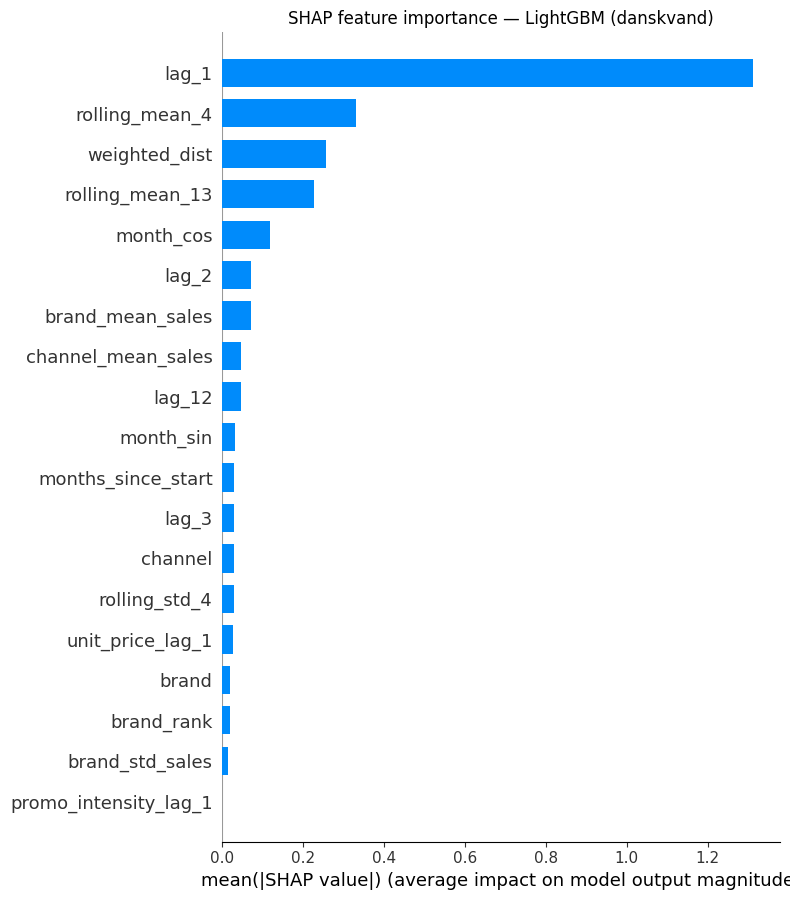

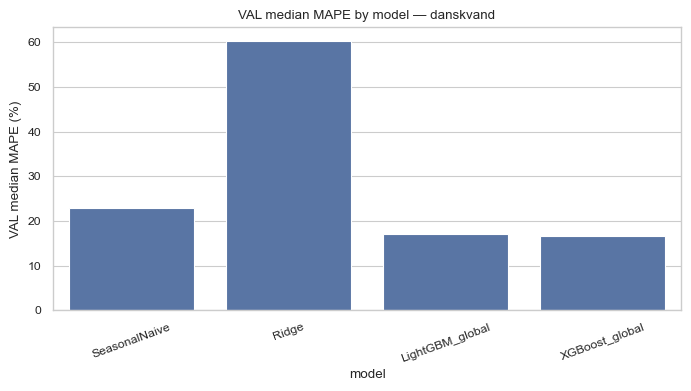


✅ Figures saved:
   docs/thesis/analysis/outputs_danskvand/figures/shap_lightgbm.png
   docs/thesis/analysis/outputs_danskvand/figures/fig1_val_mape_by_model.png

✅ Notebook complete. Models, predictions, metrics, figures saved to docs/thesis/analysis/outputs_danskvand/


In [9]:
# §8 — SHAP + figures
import shap

# SHAP for LightGBM (the headline model)
sample_n = min(2000, len(val_df))
sample = val_df.sample(sample_n, random_state=SEED).reset_index(drop=True)
X_sample = pipe_tree.transform(sample)
feature_names = NUMERIC_FEATS + CAT_FEATS

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f"SHAP feature importance — LightGBM ({CATEGORY})", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_lightgbm.png", dpi=150, bbox_inches="tight")
plt.show()

# Final figure: VAL MAPE by model bar chart
sns.set_theme(style="whitegrid", context="paper")
fig, ax = plt.subplots(figsize=(7, 4))
df_plot = pd.DataFrame(results)
sns.barplot(data=df_plot, x="model", y="mape_median", ax=ax,
            order=["SeasonalNaive", "Ridge", "LightGBM_global", "XGBoost_global"])
ax.set_title(f"VAL median MAPE by model — {CATEGORY}")
ax.set_ylabel("VAL median MAPE (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "fig1_val_mape_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Figures saved:")
print(f"   {FIGURE_DIR.relative_to(PROJECT_ROOT)}/shap_lightgbm.png")
print(f"   {FIGURE_DIR.relative_to(PROJECT_ROOT)}/fig1_val_mape_by_model.png")
print(f"\n✅ Notebook complete. Models, predictions, metrics, figures saved to {OUTPUT_DIR.relative_to(PROJECT_ROOT)}/")


### §8 — Observations + Decisions

- _Top 3 features by SHAP for LightGBM: ..._
- _Headline figure highlights: ..._

---

## End of notebook for danskvand

When all Observations+Decisions are filled in:
- `outputs_danskvand/all_models_metrics.csv` → headline table
- `outputs_danskvand/pipelines/model_lightgbm.pkl`, `model_xgboost.pkl` → trained models for agentic layer
- `outputs_danskvand/figures/shap_lightgbm.png`, `fig1_val_mape_by_model.png` → thesis figures
- `outputs_danskvand/optuna_*_trials.csv` → reproducibility appendix